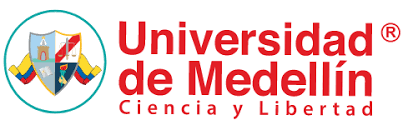

# **ANÁLISIS DE CLUSTER**

### A continuación realizaremos el Análisis de Cluster con el fin de crear agrupaciones naturales en los freelancers y segmentar.

Docente: Ingry Natalia Gómez Miranda

Estudiante: Stiven Cuéllar Mejía

#**1. Presentación de los datos**

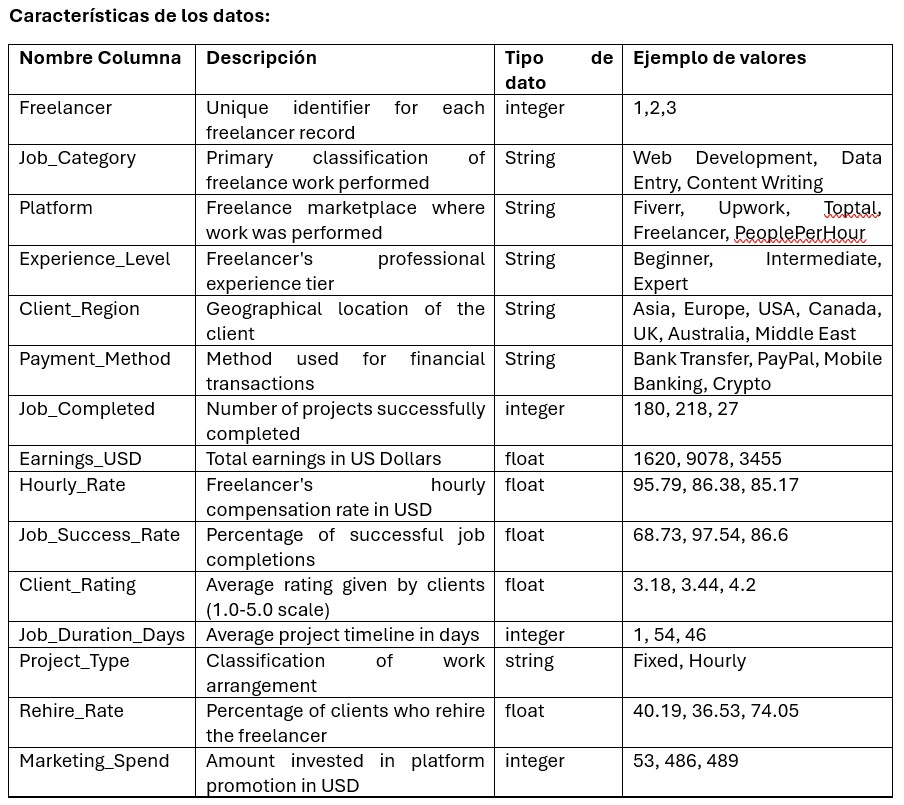

# **2. Cargar el conjunto de datos**



In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
#Cargando archivo desde el directorio de trabajo
from google.colab import files
import pandas as pd

# Cargar un archivo desde tu dispositivo local
Archivo = files.upload()

# Obtener la ruta del archivo cargado
Ruta = list(Archivo.keys())[0]

# Leer el archivo con pandas
datos = pd.read_csv(Ruta,sep=';')

# Mostrar los 10 primeros registros del DataFrame
print()
datos.head(10)

Saving freelancer_earnings_bd_PC.csv to freelancer_earnings_bd_PC.csv



,Freelancer_ID,Job_Category,Platform,Experience_Level,Client_Region,Payment_Method,Job_Completed,Earnings_USD,Hourly_Rate,Job_Success_Rate,Client_Rating,Job_Duration_Days,Project_Type,Rehire_Rate,Marketing_Spend,PC1,PC2
0,1,Web Development,Fiverr,Beginner,Asia,Mobile Banking,180,1620,95.79,68.73,3.18,1,Fixed,40.19,53,1.215381,-1.415660
1,2,App Development,Fiverr,Beginner,Australia,Mobile Banking,218,9078,86.38,97.54,3.44,54,Fixed,36.53,486,0.641236,2.277884
2,3,Web Development,Fiverr,Beginner,UK,Crypto,27,3455,85.17,86.60,4.20,46,Hourly,74.05,489,1.661109,0.301886
3,4,Data Entry,PeoplePerHour,Intermediate,Asia,Bank Transfer,17,5577,14.37,79.93,4.47,41,Hourly,27.58,67,-2.145490,-0.812147
4,5,Digital Marketing,Upwork,Expert,Asia,Crypto,245,5898,99.37,57.80,5.00,41,Hourly,69.09,489,2.234485,1.909123
5,6,Customer Support,Toptal,Beginner,Europe,Crypto,280,6867,43.04,57.80,4.87,8,Fixed,43.88,290,0.361841,1.110739
6,7,Web Development,Fiverr,Beginner,USA,Crypto,96,1677,20.50,52.90,4.29,32,Hourly,45.99,343,0.339009,-1.059209
7,8,Data Entry,Toptal,Beginner,Australia,Bank Transfer,112,6193,82.15,93.31,3.84,30,Fixed,31.59,168,-0.352024,0.411004
8,9,Content Writing,Toptal,Intermediate,USA,Crypto,233,8446,26.44,80.06,4.27,46,Fixed,50.11,396,-0.184899,1.368574
9,10,Data Entry,PeoplePerHour,Beginner,Middle East,Mobile Banking,156,6608,54.99,85.40,4.57,52,Hourly,32.76,160,-1.184943,0.724199


In [9]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1950 entries, 0 to 1949
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Freelancer_ID      1950 non-null   int64  
 1   Job_Category       1950 non-null   object 
 2   Platform           1950 non-null   object 
 3   Experience_Level   1950 non-null   object 
 4   Client_Region      1950 non-null   object 
 5   Payment_Method     1950 non-null   object 
 6   Job_Completed      1950 non-null   int64  
 7   Earnings_USD       1950 non-null   int64  
 8   Hourly_Rate        1950 non-null   float64
 9   Job_Success_Rate   1950 non-null   float64
 10  Client_Rating      1950 non-null   float64
 11  Job_Duration_Days  1950 non-null   int64  
 12  Project_Type       1950 non-null   object 
 13  Rehire_Rate        1950 non-null   float64
 14  Marketing_Spend    1950 non-null   int64  
 15  PC1                1950 non-null   float64
 16  PC2                1950 

In [10]:
# Cargar las librerías
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram
from sklearn.cluster import AgglomerativeClustering
import scipy.cluster.hierarchy as sch
from sklearn.cluster import KMeans
from scipy.spatial import ConvexHull
import matplotlib.pyplot as plt
import pandas as pd
from scipy.cluster.hierarchy import fcluster


# **3. Análisis de cluster**

**3.1 CLUSTER con todos los datos**

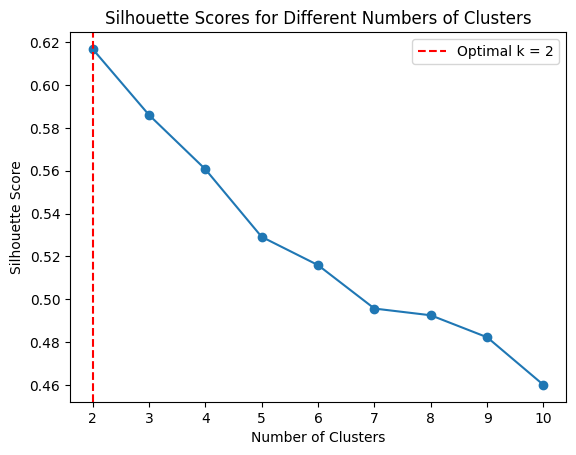

In [27]:
#Coeficiente de Silhoutte para el número de grupos
data=datos[["Job_Completed","Earnings_USD","Hourly_Rate","Job_Success_Rate","Client_Rating","Job_Duration_Days","Rehire_Rate","Marketing_Spend"]]

def fviz_nbclust(data, max_k):
    silhouette_scores = []
    for k in range(2, max_k + 1):
        kmeans = KMeans(n_clusters=k)
        kmeans.fit(data)
        score = silhouette_score(data, kmeans.labels_)
        silhouette_scores.append(score)

    plt.plot(range(2, max_k + 1), silhouette_scores, marker='o')
    plt.title('Silhouette Scores for Different Numbers of Clusters')
    plt.xlabel('Number of Clusters')
    plt.ylabel('Silhouette Score')

    # Find the optimal number of clusters (k)
    optimal_k = np.argmax(silhouette_scores) + 2  # Add 2 because the range starts from 2

    # Add a vertical line at the optimal k
    plt.axvline(x=optimal_k, color='r', linestyle='--', label=f'Optimal k = {optimal_k}')
    plt.legend()

    plt.show()

# Call the function with the desired maximum number of clusters
fviz_nbclust(data, max_k=10)

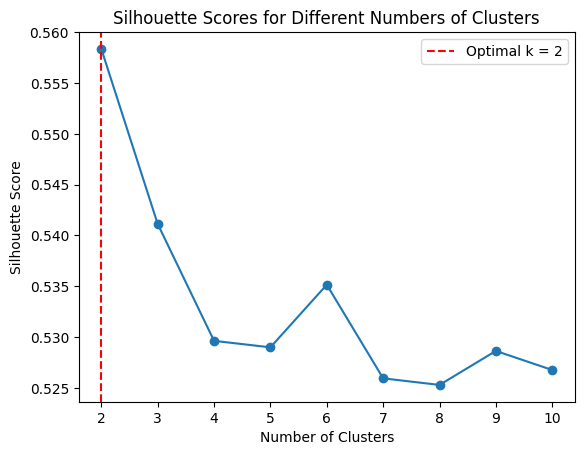

In [28]:
#Coeficiente de Silhoutte para el número de grupos
data=datos[["PC1"]]

def fviz_nbclust(data, max_k):
    silhouette_scores = []
    for k in range(2, max_k + 1):
        kmeans = KMeans(n_clusters=k)
        kmeans.fit(data)
        score = silhouette_score(data, kmeans.labels_)
        silhouette_scores.append(score)

    plt.plot(range(2, max_k + 1), silhouette_scores, marker='o')
    plt.title('Silhouette Scores for Different Numbers of Clusters')
    plt.xlabel('Number of Clusters')
    plt.ylabel('Silhouette Score')

    # Find the optimal number of clusters (k)
    optimal_k = np.argmax(silhouette_scores) + 2  # Add 2 because the range starts from 2

    # Add a vertical line at the optimal k
    plt.axvline(x=optimal_k, color='r', linestyle='--', label=f'Optimal k = {optimal_k}')
    plt.legend()

    plt.show()

# Call the function with the desired maximum number of clusters
fviz_nbclust(data, max_k=10)

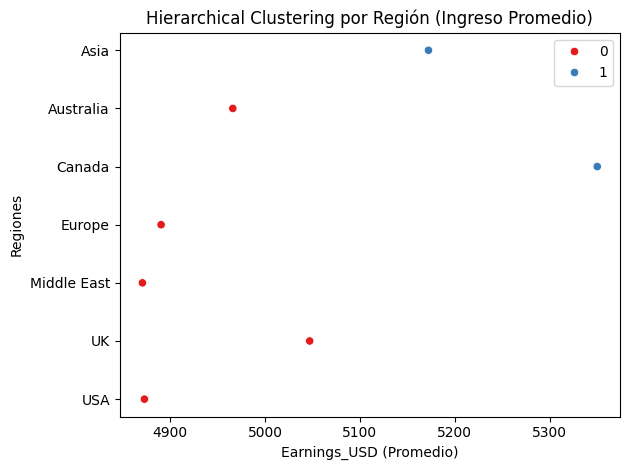

In [29]:
# Agrupar datos por región y calcular el ingreso promedio
region_df = datos.groupby('Client_Region')['Earnings_USD'].mean().reset_index()

# El cálculo del cluster N=2 GRUPOS
regiones = region_df.iloc[:, 0].values
data = region_df[['Earnings_USD']]  # usamos solo ingresos para el clustering
model = AgglomerativeClustering(n_clusters=2)
model.fit(data)
labels = model.labels_

# Asociar regiones con sus clústeres
cluster_df = pd.DataFrame({'Regiones': regiones, 'Cluster': labels})

# Visualización
sns.scatterplot(x=data.iloc[:, 0], y=regiones, hue=labels, palette='Set1')
plt.title('Hierarchical Clustering por Región (Ingreso Promedio)')
plt.xlabel('Earnings_USD (Promedio)')
plt.ylabel('Regiones')
plt.tight_layout()
plt.show()

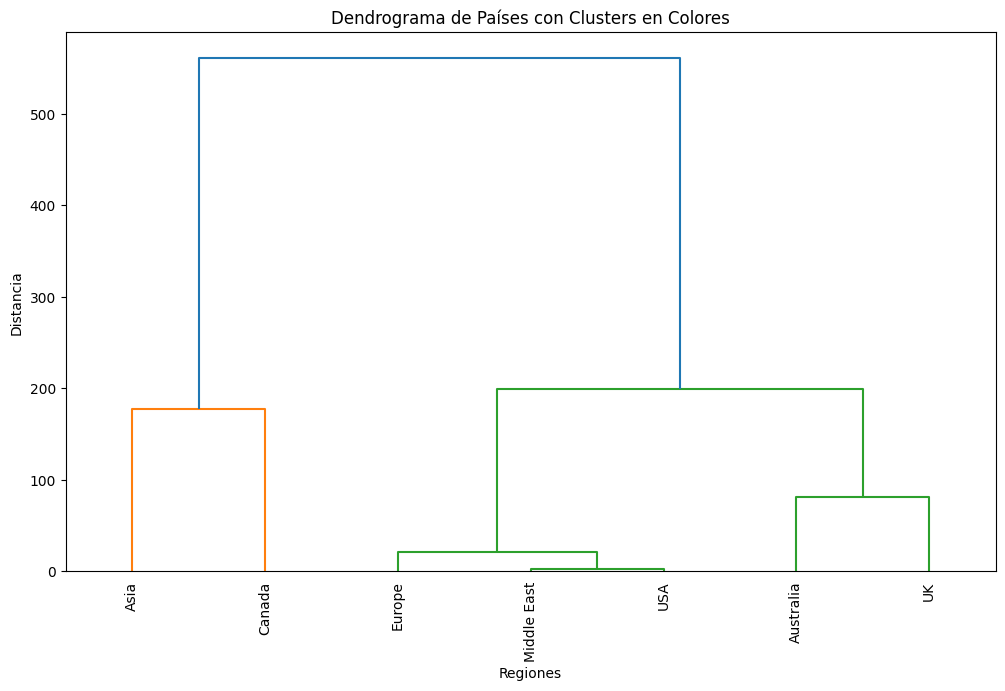

In [30]:
#El dendograma

model = sch.linkage(data, method='ward')

threshold = 0.7 * max(model[:, 2])  # Se basa en la distancia máxima para cortar


# Graficar el dendrograma con etiquetas de países y colores para los clusters
plt.figure(figsize=(12, 7))
sch.dendrogram(
    model,
    labels=regiones,
    leaf_rotation=90,
    leaf_font_size=10,
    color_threshold=threshold  # Define el punto de corte para los colores
)

plt.title('Dendrograma de Países con Clusters en Colores')
plt.xlabel('Regiones')
plt.ylabel('Distancia')
plt.show()

In [31]:
# Obtener las etiquetas del cluster
cluster_df.to_csv('cluster_puras2.csv', index=False)

#Guardar el .csv
cluster_df.to_csv('cluster_puras2.csv', index=False)

# Display the DataFrame
cluster_df


,Regiones,Cluster
0,Asia,1
1,Australia,0
2,Canada,1
3,Europe,0
4,Middle East,0
5,UK,0
6,USA,0


**3.2 CINCO CLUSTER**

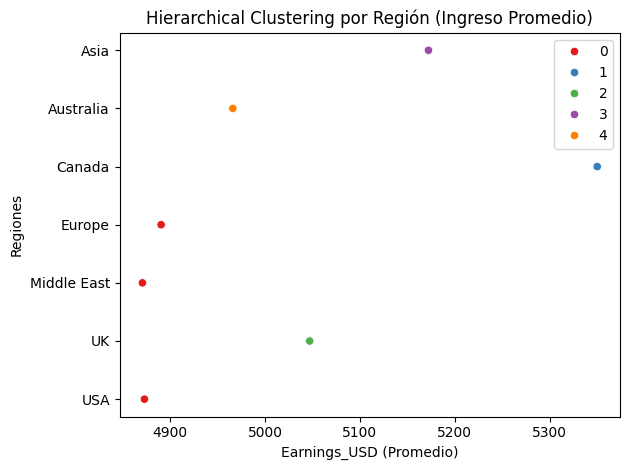

In [32]:
# Agrupar datos por región y calcular el ingreso promedio
region_df = datos.groupby('Client_Region')['Earnings_USD'].mean().reset_index()

# El cálculo del cluster N=2 GRUPOS
regiones = region_df.iloc[:, 0].values
data = region_df[['Earnings_USD']]  # usamos solo ingresos para el clustering
model = AgglomerativeClustering(n_clusters=5)
model.fit(data)
labels = model.labels_

# Asociar regiones con sus clústeres
cluster_df = pd.DataFrame({'Regiones': regiones, 'Cluster': labels})

# Visualización
sns.scatterplot(x=data.iloc[:, 0], y=regiones, hue=labels, palette='Set1')
plt.title('Hierarchical Clustering por Región (Ingreso Promedio)')
plt.xlabel('Earnings_USD (Promedio)')
plt.ylabel('Regiones')
plt.tight_layout()
plt.show()

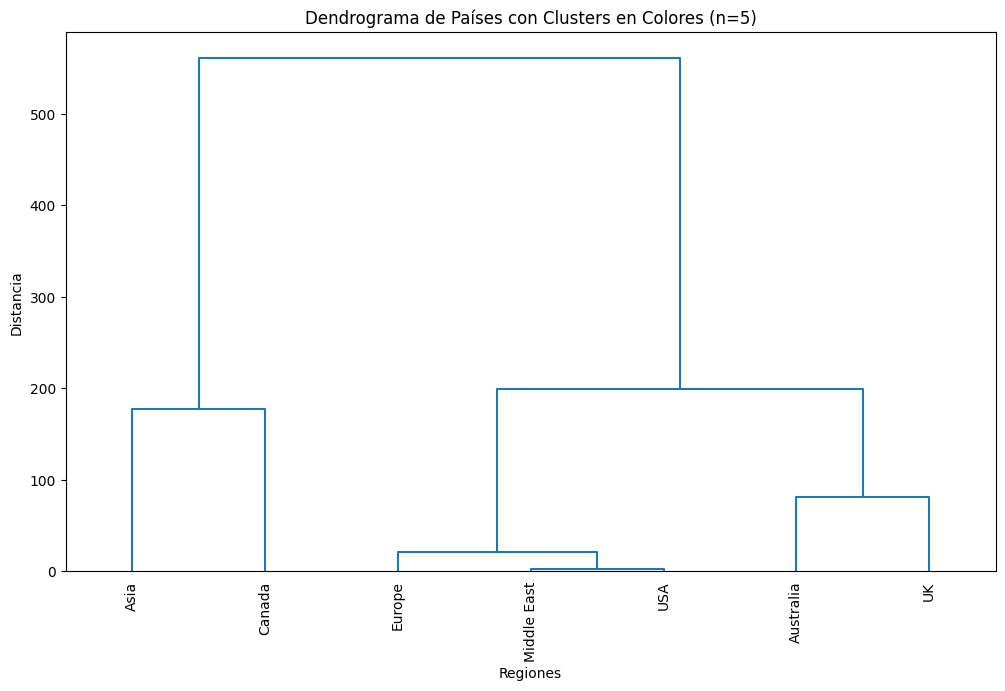

In [34]:
#Dendograma para 5 grupos

# Generar la matriz de enlaces con el método de Ward
model_linkage = sch.linkage(data, method='ward')

# Obtener etiquetas exactas de 5 clusters
cluster_labels = fcluster(model_linkage, t=5, criterion='maxclust')

# Asegurar que el umbral de corte refleje 5 clusters
distances = model_linkage[:, 2]
distances_sorted = np.sort(distances)
color_threshold = distances_sorted[-6]  # Ajuste preciso para 5 clusters

# Verificar si hay menos de 5 colores y ajustar si es necesario
dn = dendrogram(
    model_linkage,
    labels=regiones,
    leaf_rotation=90,
    leaf_font_size=10,
    color_threshold=color_threshold
)

# Obtener los colores usados en el dendrograma
colors_used = set(dn['leaves_color_list'])

# Si hay menos de 5 colores, ajustar el umbral y volver a dibujar
if len(colors_used) < 5:
    plt.close()  # Cerrar el primer gráfico antes de generar el nuevo
    color_threshold = distances_sorted[-6]  # Reducimos el umbral para forzar más colores

    # Graficar el dendrograma corregido
    plt.figure(figsize=(12, 7))
    dendrogram(
       model_linkage,
       labels=regiones,
       leaf_rotation=90,
       leaf_font_size=10,
       color_threshold=color_threshold
    )

plt.title('Dendrograma de Países con Clusters en Colores (n=5)')
plt.xlabel('Regiones')
plt.ylabel('Distancia')
plt.show()






In [35]:
# Obtener las etiquetas del cluster
cluster_df.to_csv('cluster_puras5.csv', index=False)

#Guardar el .csv
cluster_df.to_csv('cluster_puras5.csv', index=False)

# Display the DataFrame
cluster_df

,Regiones,Cluster
0,Asia,3
1,Australia,4
2,Canada,1
3,Europe,0
4,Middle East,0
5,UK,2
6,USA,0


**3.3 EJERCICIO: CLUSTER con todos los COMPONENTES**